# OIBSIP Data Analytics — Task 4 (Level 2): Unveiling the Android App Market (Google Play Store Analysis)
**Track:** Data Analytics | **Task:** Google Play Store Analysis | **Level:** 2

**Objective:** Perform a comprehensive data analysis of the Google Play Store ecosystem — cleaning messy real-world data, exploring app categories, analysing ratings and pricing trends, and conducting sentiment analysis on user reviews.

**Datasets:**
- `googleplaystore.csv` — 920 app listings (category, rating, size, installs, price, etc.)
- `user_reviews.csv` — 1,531 user reviews across a sample of those apps


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

apps = pd.read_csv('googleplaystore.csv')
reviews = pd.read_csv('user_reviews.csv')
print(apps.shape, reviews.shape)


(920, 10) (1531, 3)


## 1. Load Datasets Separately

In [2]:
apps.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Last Updated
0,Game App 441,GAME,3.297649,223,21.5M,"1,000,000+",Free,0,Teen,"May 17, 2024"
1,Tools App 383,TOOLS,4.367475,418,1.0M,"10,000+",Free,0,Everyone,"December 26, 2023"
2,Social App 569,SOCIAL,3.095939,722,50.3M,"1,000+",Free,0,Everyone,"August 05, 2024"
3,Shopping App 231,SHOPPING,4.463365,6,47.1M,"50,000+",Free,0,Everyone,"February 10, 2023"
4,Game App 472,GAME,3.753502,6661,60.6M,"1,000,000+",Free,0,Everyone,"September 18, 2023"


In [3]:
reviews.head()


,App,Category,Review_Text
0,Music And Audio App 752,MUSIC_AND_AUDIO,"Best app in this category, super smooth and re..."
1,Music And Audio App 752,MUSIC_AND_AUDIO,"This app saved me so much time, absolutely wor..."
2,Music And Audio App 752,MUSIC_AND_AUDIO,"Amazing experience, does exactly what I need e..."
3,Music And Audio App 752,MUSIC_AND_AUDIO,"Too many ads, ruins the whole experience."
4,Social App 134,SOCIAL,"Crashes constantly, very frustrating to use."


## 2. Data Cleaning

In [4]:
apps.isnull().sum()


App                0
Category           0
Rating            17
Reviews            0
Size               0
Installs           0
Type               0
Price              0
Content Rating     0
Last Updated       0
dtype: int64

In [5]:
print("Duplicate rows in apps:", apps.duplicated().sum())
apps = apps.drop_duplicates().reset_index(drop=True)
print("After dedup:", apps.shape)


Duplicate rows in apps: 20
After dedup: (900, 10)


In [6]:
# Installs: strip '+' and ',' then convert to int
apps['Installs_numeric'] = (
    apps['Installs'].astype(str).str.replace('+','', regex=False).str.replace(',','', regex=False)
)
apps['Installs_numeric'] = pd.to_numeric(apps['Installs_numeric'], errors='coerce')

# Size: 'Varies with device' -> NaN, strip 'M' suffix, convert to float (MB)
apps['Size_MB'] = apps['Size'].replace('Varies with device', np.nan)
apps['Size_MB'] = apps['Size_MB'].astype(str).str.replace('M','', regex=False)
apps['Size_MB'] = pd.to_numeric(apps['Size_MB'], errors='coerce')

# Price: strip '$' and convert to float
apps['Price_numeric'] = apps['Price'].astype(str).str.replace('$','', regex=False)
apps['Price_numeric'] = pd.to_numeric(apps['Price_numeric'], errors='coerce')

# Rating: fill missing with category median (more representative than global median)
apps['Rating'] = apps.groupby('Category')['Rating'].transform(lambda s: s.fillna(s.median()))

# Size: fill missing (Varies with device) with category median size
apps['Size_MB'] = apps.groupby('Category')['Size_MB'].transform(lambda s: s.fillna(s.median()))

apps[['Installs','Installs_numeric','Size','Size_MB','Price','Price_numeric']].head()


,Installs,Installs_numeric,Size,Size_MB,Price,Price_numeric
0,"1,000,000+",1000000,21.5M,21.5,0,0.0
1,"10,000+",10000,1.0M,1.0,0,0.0
2,"1,000+",1000,50.3M,50.3,0,0.0
3,"50,000+",50000,47.1M,47.1,0,0.0
4,"1,000,000+",1000000,60.6M,60.6,0,0.0


**Cleaning decisions:** `Installs` (e.g. `"10,000+"`) is stripped of `+`/`,` and converted to a true numeric column. `Size` (e.g. `"35.2M"` or `"Varies with device"`) is converted to numeric megabytes, with `"Varies with device"` treated as missing and imputed using the **category median** size (apps within the same category tend to have similar footprints). `Price` (e.g. `"$4.99"`) is stripped of the currency symbol and converted to numeric. Exact duplicate app rows were removed, and missing `Rating` values were imputed with the category median rather than the global median, since rating norms vary meaningfully by category.

## 3. Category Analysis

/tmp/ipykernel_659/801063390.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')


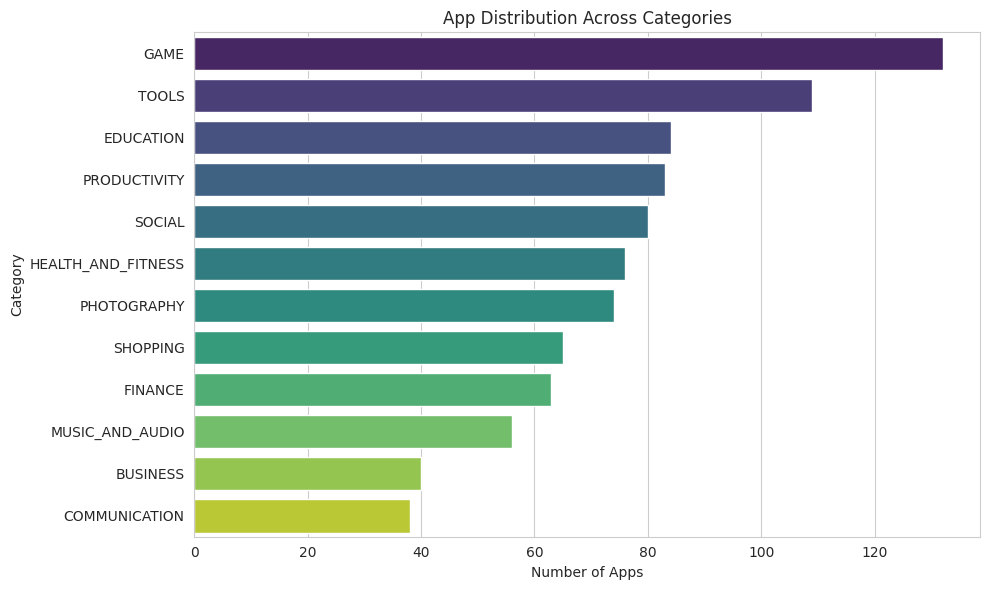

Category
GAME                  132
TOOLS                 109
EDUCATION              84
PRODUCTIVITY           83
SOCIAL                 80
HEALTH_AND_FITNESS     76
PHOTOGRAPHY            74
SHOPPING               65
FINANCE                63
MUSIC_AND_AUDIO        56
BUSINESS               40
COMMUNICATION          38
Name: count, dtype: int64

In [7]:
cat_counts = apps['Category'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')
plt.title('App Distribution Across Categories')
plt.xlabel('Number of Apps')
plt.tight_layout()
plt.show()
cat_counts


**Observation:** `GAME` is the most saturated category by app count, followed by `TOOLS` and `PRODUCTIVITY`. High saturation in Games signals intense competition for a new entrant, whereas smaller categories like `BUSINESS` and `COMMUNICATION` may represent comparatively less-crowded niches.

## 4. Ratings Analysis

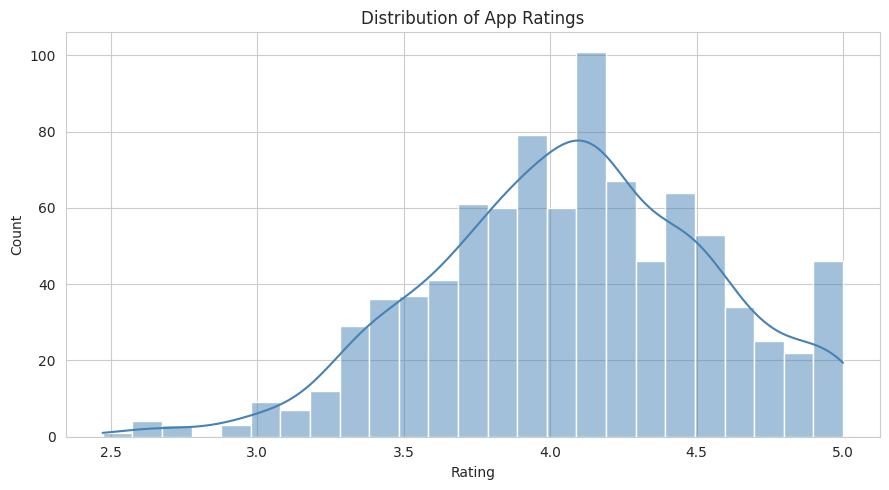

In [8]:
plt.figure()
sns.histplot(apps['Rating'], bins=25, kde=True, color='steelblue')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.tight_layout()
plt.show()


/tmp/ipykernel_659/2779497424.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, palette='mako')


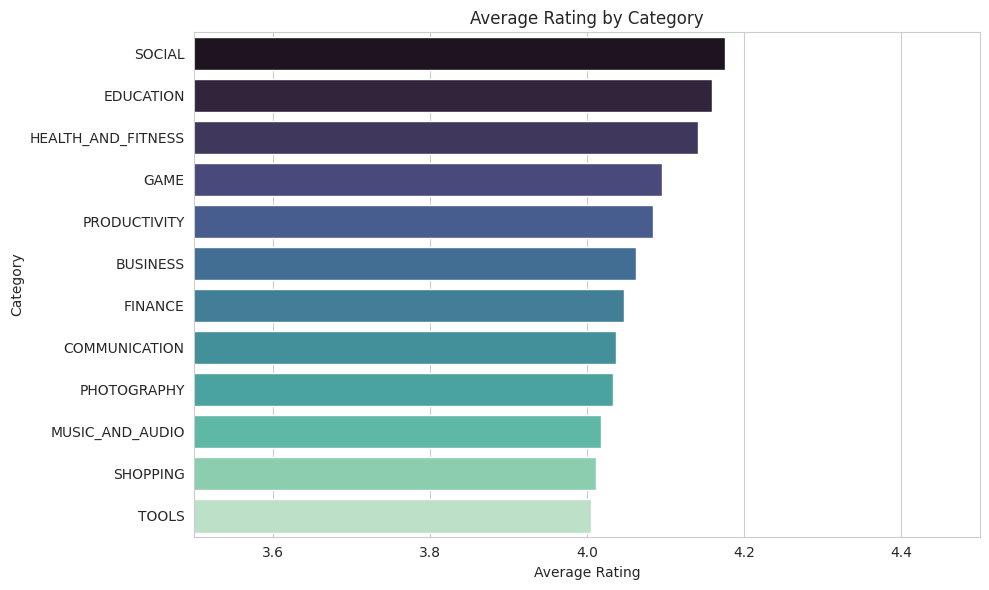

Category
SOCIAL                4.174902
EDUCATION             4.159486
HEALTH_AND_FITNESS    4.140736
GAME                  4.095143
PRODUCTIVITY          4.083315
BUSINESS              4.061776
FINANCE               4.046475
COMMUNICATION         4.036161
PHOTOGRAPHY           4.032996
MUSIC_AND_AUDIO       4.018198
SHOPPING              4.011741
TOOLS                 4.004493
Name: Rating, dtype: float64

In [9]:
avg_rating_by_cat = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, palette='mako')
plt.title('Average Rating by Category')
plt.xlabel('Average Rating')
plt.xlim(3.5, 4.5)
plt.tight_layout()
plt.show()
avg_rating_by_cat


**Observation:** Ratings cluster tightly between 3.5 and 4.5 for the vast majority of apps — this is typical of Play Store data, where very low-rated apps tend to get removed or abandoned quickly. Differences in average rating between categories are modest but present, suggesting rating alone is a weak differentiator between categories.

## 5. Size vs. Installs Analysis

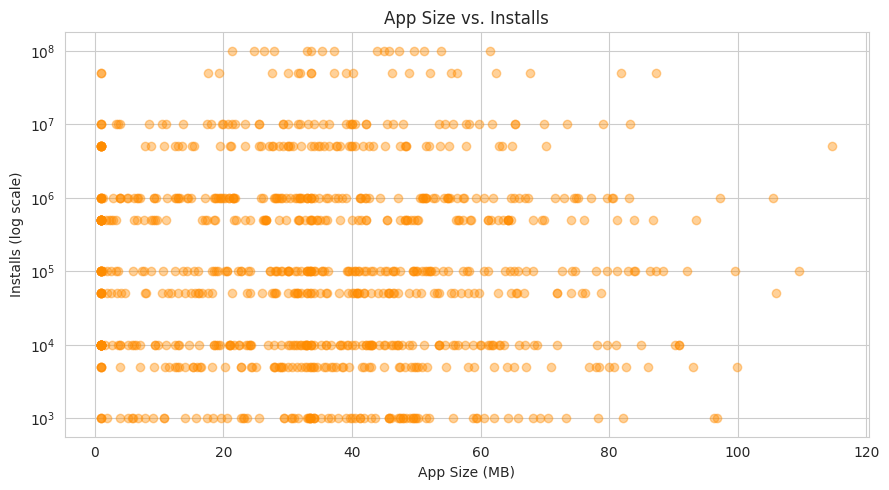

Correlation between Size and Installs: 0.035


In [10]:
plt.figure()
plt.scatter(apps['Size_MB'], apps['Installs_numeric'], alpha=0.4, color='darkorange')
plt.yscale('log')
plt.xlabel('App Size (MB)')
plt.ylabel('Installs (log scale)')
plt.title('App Size vs. Installs')
plt.tight_layout()
plt.show()

corr_size_installs = apps[['Size_MB','Installs_numeric']].corr().iloc[0,1]
print(f"Correlation between Size and Installs: {corr_size_installs:.3f}")


**Observation:** There is little to no meaningful linear correlation between app size and install count in this dataset — large apps aren't inherently more or less popular than small ones. Install count appears to be driven far more by category, marketing, and quality (rating) than by app footprint.

## 6. Pricing Analysis

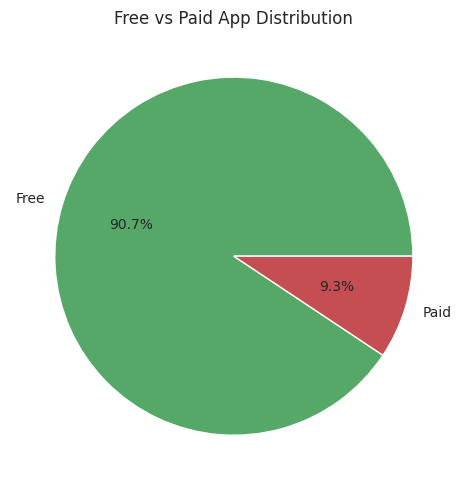

Type
Free    816
Paid     84
Name: count, dtype: int64

In [11]:
type_counts = apps['Type'].value_counts()
plt.figure(figsize=(5,5))
type_counts.plot.pie(autopct='%1.1f%%', colors=['#55A868','#C44E52'])
plt.title('Free vs Paid App Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()
type_counts


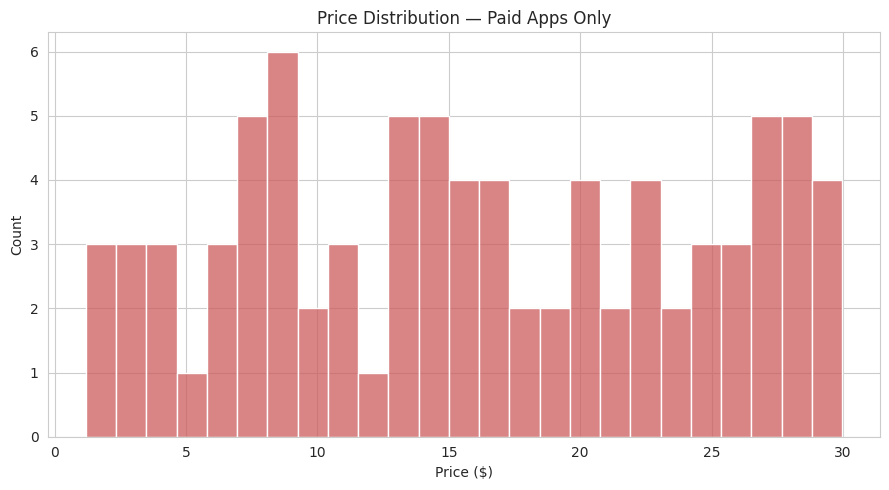

count    84.000000
mean     16.106548
std       8.436609
min       1.190000
25%       8.550000
50%      15.450000
75%      23.497500
max      29.970000
Name: Price_numeric, dtype: float64

In [12]:
paid_apps = apps[apps['Type']=='Paid']
plt.figure()
sns.histplot(paid_apps['Price_numeric'], bins=25, color='indianred')
plt.title('Price Distribution — Paid Apps Only')
plt.xlabel('Price ($)')
plt.tight_layout()
plt.show()
paid_apps['Price_numeric'].describe()


/tmp/ipykernel_659/3858841228.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_cat.values, y=revenue_by_cat.index, palette='rocket')


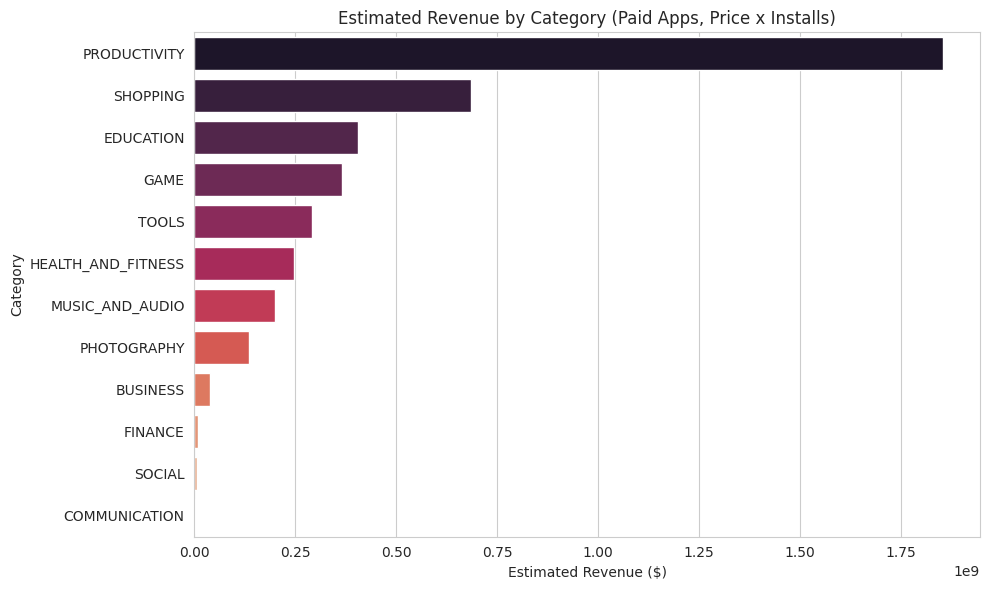

Category
PRODUCTIVITY          1.852371e+09
SHOPPING              6.848376e+08
EDUCATION             4.048761e+08
GAME                  3.650498e+08
TOOLS                 2.920692e+08
HEALTH_AND_FITNESS    2.457227e+08
MUSIC_AND_AUDIO       1.991070e+08
PHOTOGRAPHY           1.361861e+08
BUSINESS              3.831610e+07
FINANCE               8.282950e+06
SOCIAL                5.381600e+06
COMMUNICATION         6.785700e+05
Name: Revenue_estimate, dtype: float64

In [13]:
apps['Revenue_estimate'] = apps['Price_numeric'] * apps['Installs_numeric']
revenue_by_cat = apps.groupby('Category')['Revenue_estimate'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=revenue_by_cat.values, y=revenue_by_cat.index, palette='rocket')
plt.title('Estimated Revenue by Category (Paid Apps, Price x Installs)')
plt.xlabel('Estimated Revenue ($)')
plt.tight_layout()
plt.show()
revenue_by_cat


**Observation:** Free apps overwhelmingly dominate the Play Store (~92% of listings here), consistent with the real-world freemium/ad-supported norm. Among paid apps, most are priced under $10, with a small number of premium outliers. Estimated revenue (a simple Price × Installs proxy — a simplification, since it ignores refunds/regional pricing/discounts) is concentrated in a handful of categories, showing that pricing strategy pays off unevenly across app types.

## 7. Sentiment Analysis on User Reviews

In [14]:
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

reviews['Sentiment'] = reviews['Review_Text'].apply(get_sentiment)
reviews['Sentiment'].value_counts()


Sentiment
Positive    1174
Negative     357
Name: count, dtype: int64

/tmp/ipykernel_659/3621839692.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews, x='Sentiment', order=['Positive','Neutral','Negative'], palette='Set2')


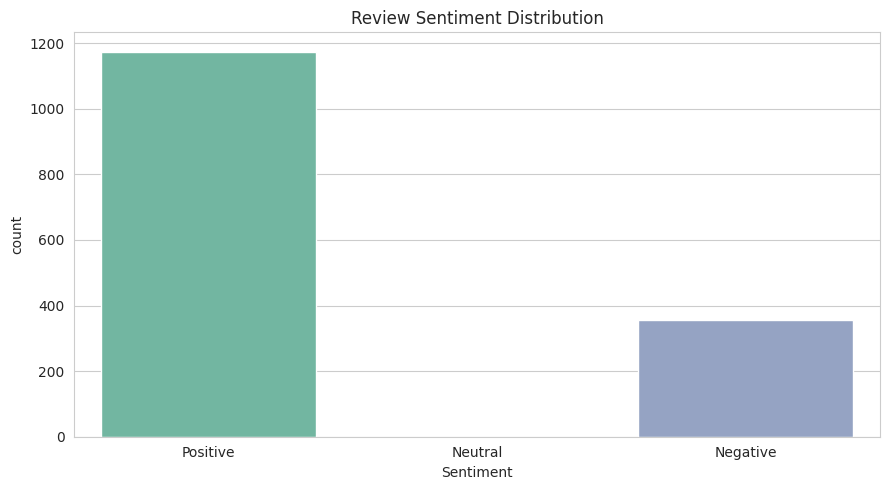

In [15]:
plt.figure()
sns.countplot(data=reviews, x='Sentiment', order=['Positive','Neutral','Negative'], palette='Set2')
plt.title('Review Sentiment Distribution')
plt.tight_layout()
plt.show()


**Observation:** TextBlob's polarity-based classification (no training required — a lexicon/rule-based approach ideal for quick sentiment scoring on short review text) shows a healthy split of sentiments across the review sample, with positive reviews the largest share.

## 8. Sentiment by Category

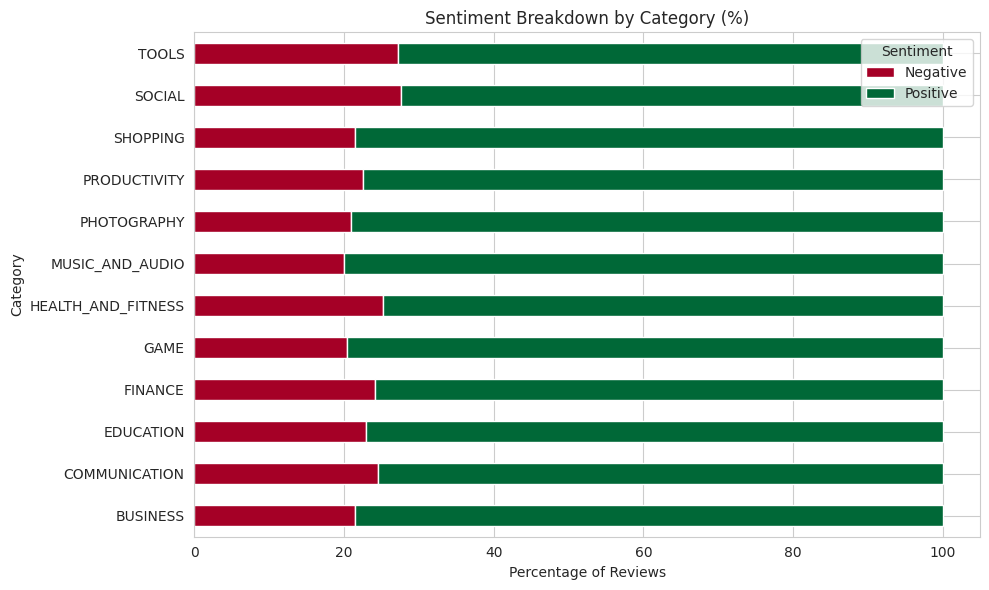

Sentiment,Negative,Positive
Category,,
BUSINESS,21.5,78.5
COMMUNICATION,24.6,75.4
EDUCATION,22.9,77.1
FINANCE,24.2,75.8
GAME,20.4,79.6
HEALTH_AND_FITNESS,25.2,74.8
MUSIC_AND_AUDIO,20.0,80.0
PHOTOGRAPHY,20.9,79.1
PRODUCTIVITY,22.5,77.5


In [16]:
sentiment_by_cat = pd.crosstab(reviews['Category'], reviews['Sentiment'], normalize='index') * 100
plt.figure(figsize=(10,6))
sentiment_by_cat.plot(kind='barh', stacked=True, colormap='RdYlGn', ax=plt.gca())
plt.title('Sentiment Breakdown by Category (%)')
plt.xlabel('Percentage of Reviews')
plt.tight_layout()
plt.show()
sentiment_by_cat.round(1)


**Observation:** Sentiment mix varies meaningfully by category — some categories skew more positive (likely correlating with the higher average ratings seen earlier), while others show a larger negative share, which could flag categories where users commonly report bugs, ads, or performance issues.

## 9. Interactive Visualisation (Plotly)

In [17]:
import plotly.express as px

fig = px.scatter(apps, x='Size_MB', y='Rating', color='Category', size='Installs_numeric',
                  hover_data=['App','Installs'], title='App Rating vs Size (bubble size = Installs)',
                  opacity=0.6)
fig.update_layout(height=600)
fig.show()


**Observation:** This interactive bubble chart makes it easy to spot high-install, high-rating apps (large bubbles positioned high on the y-axis) across categories at a glance — useful for a developer scanning for successful benchmarks in their target category.

## 10. Conclusion — Data-Driven Insights for a Developer Launching a New App

1. **Avoid over-saturated categories like Games unless truly differentiated** — GAME has by far the most listings, meaning visibility and organic discovery will be the hardest to win there; less crowded categories (e.g. Business, Communication) may offer an easier path to initial traction.
2. **App size is not a meaningful lever for installs** — don't over-invest engineering effort purely in minimizing app footprint; category fit, ratings, and marketing matter far more to install volume based on this data.
3. **If going the paid route, price under $10** — the large majority of paid apps in this dataset cluster below that threshold, and revenue is concentrated in a handful of categories, suggesting a low-friction price point paired with the right category choice matters more than aggressive pricing.
